This file will be used to explore Kilosort4 output data.

In [1]:
# imports 
from pathlib import Path
import numpy as np
import pandas as pd
from kilosort.io import load_ops
from kilosort.data_tools import (
    mean_waveform, cluster_templates, get_good_cluster, get_cluster_spikes,
    get_spike_waveforms, get_best_channels
    )

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams

%matplotlib inline

In [14]:
# outputs saved to results_dir
VD_results_dir = Path(r"C:\Users\social\Desktop\temp_Brune\SpikeExplore\kilosort_output\buzsaki_20260311\CAR")
DV_results_dir = Path(r"C:\Users\social\Desktop\temp_Brune\SpikeExplore\kilosort_output\buzsaki_20260311\CAR_DV")

In [ ]:
VD_ops = load_ops(VD_results_dir / 'ops.npy')
DV_ops = load_ops(DV_results_dir / 'ops.npy')

VD_chan_map =  np.load(VD_results_dir / 'channel_map.npy')
DV_chan_map =  np.load(DV_results_dir / 'channel_map.npy')

VD_chan_positions = np.load(VD_results_dir / 'channel_positions.npy')
DV_chan_positions = np.load(DV_results_dir / 'channel_positions.npy')

VD_chan_shanks = np.load(VD_results_dir / 'channel_shanks.npy')
DV_chan_shanks = np.load(DV_results_dir / 'channel_shanks.npy')

# =============== #

VD_camps = pd.read_csv(VD_results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values
DV_camps = pd.read_csv(DV_results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values

VD_contam_pct = pd.read_csv(VD_results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values
DV_contam_pct = pd.read_csv(DV_results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values

VD_templates =  np.load(VD_results_dir / 'templates.npy')
DV_templates =  np.load(DV_results_dir / 'templates.npy')

VD_chan_best = (VD_templates**2).sum(axis=1).argmax(axis=-1)
DV_chan_best = (DV_templates**2).sum(axis=1).argmax(axis=-1)

VD_amplitudes = np.load(VD_results_dir / 'amplitudes.npy')
DV_amplitudes = np.load(DV_results_dir / 'amplitudes.npy')

VD_st = np.load(VD_results_dir / 'spike_times.npy')
DV_st = np.load(DV_results_dir / 'spike_times.npy')

VD_clu = np.load(VD_results_dir / 'spike_clusters.npy')
DV_clu = np.load(DV_results_dir / 'spike_clusters.npy')

VD_firing_rates = np.unique(VD_clu, return_counts=True)[1] * 30000 / VD_st.max()
DV_firing_rates = np.unique(DV_clu, return_counts=True)[1] * 30000 / DV_st.max()

VD_dshift = VD_ops['dshift']
DV_dshift = DV_ops['dshift']

In [22]:
print(np.sort(VD_chan_best))
print(np.sort(DV_chan_best))

print(len(VD_templates), len(DV_templates))

[  0   0   0   3   5   7   9  12  15  15  17  18  21  22  22  23  23  23
  26  26  26  27  28  28  28  28  29  29  30  31  31  33  33  34  35  35
  37  37  39  39  40  40  41  43  43  44  45  45  47  47  49  49  50  51
  51  52  53  53  54  54  55  55  57  57  58  59  61  61  61  63  63  64
  65  65  65  66  67  69  69  71  74  74  75  75  75  75  75  75  76  77
  77  77  77  77  78  78  79  80  80  80  80  81  81  81  82  84  86  86
  86  87  87  89  89  89  89  89  91  91  91  92  92  93  93  93  93  94
  94  95  95  96  96  96  97  97  98  99 101 101 101 102 103 104 104 105
 105 106 106 107 107 108 108 108 109 109 111 111 111 111 112 113 113 114
 114 115 115 116 116 116 116 117 117 117 117 118 119 119 119 119]
[  0   0   0   0   2   3   3   4   4   6   6   7   7   8   8   9   9  10
  10  11  12  12  14  14  16  16  17  17  18  18  20  21  21  22  22  24
  24  24  26  26  27  27  28  28  30  30  30  31  32  32  33  33  33  33
  33  35  35  35  35  35  36  36  36  38  38  39  39  40  

In [15]:
print(f"templates array shape: {templates.shape}")
print(f"cluster array shape: {clu.shape}. This array contains the cluster ID of each spike. There are {np.max(clu)} clusters")
print(clu[100])

templates array shape: (40, 61, 38)
cluster array shape: (1396504,). This array contains the cluster ID of each spike. There are 39 clusters
4


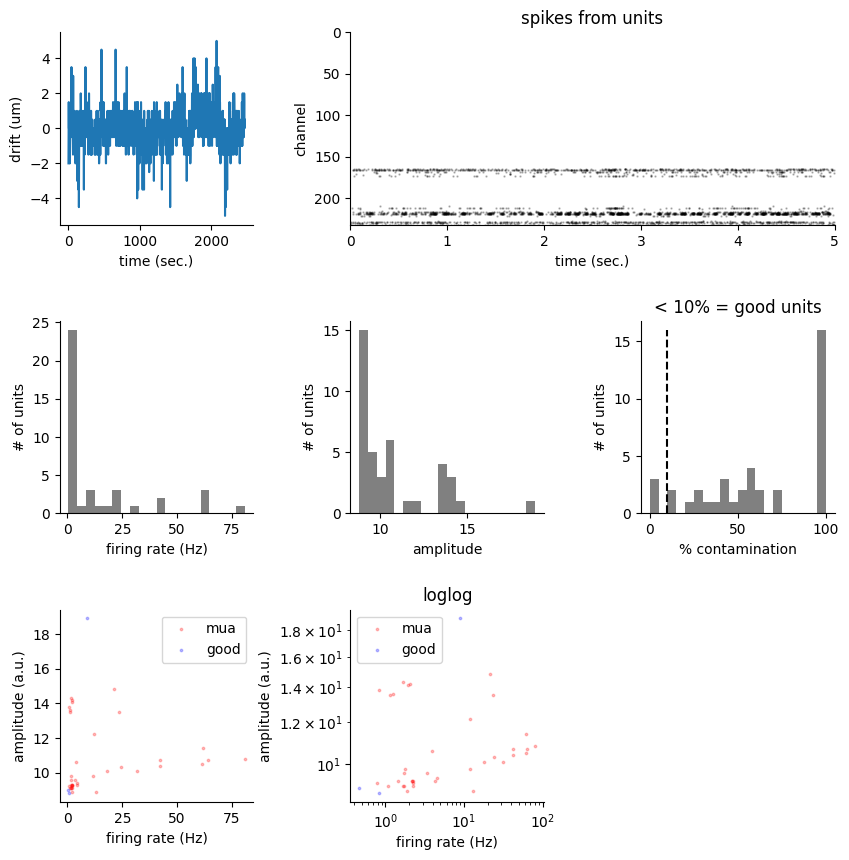

In [16]:

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
gray = .5 * np.ones(3)

fig = plt.figure(figsize=(10,10), dpi=100)
grid = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.5)

ax = fig.add_subplot(grid[0,0])
ax.plot(np.arange(0, ops['Nbatches'])*2, dshift)
ax.set_xlabel('time (sec.)')
ax.set_ylabel('drift (um)')

ax = fig.add_subplot(grid[0,1:])
t0 = 0
t1 = np.nonzero(st > ops['fs']*5)[0][0]
ax.scatter(st[t0:t1]/30000., chan_best[clu[t0:t1]], s=0.5, color='k', alpha=0.25)
ax.set_xlim([0, 5])
ax.set_ylim([chan_map.max(), 0])
ax.set_xlabel('time (sec.)')
ax.set_ylabel('channel')
ax.set_title('spikes from units')

ax = fig.add_subplot(grid[1,0])
nb=ax.hist(firing_rates, 20, color=gray)
ax.set_xlabel('firing rate (Hz)')
ax.set_ylabel('# of units')

ax = fig.add_subplot(grid[1,1])
nb=ax.hist(camps, 20, color=gray)
ax.set_xlabel('amplitude')
ax.set_ylabel('# of units')

ax = fig.add_subplot(grid[1,2])
nb=ax.hist(np.minimum(100, contam_pct), np.arange(0,105,5), color=gray)
ax.plot([10, 10], [0, nb[0].max()], 'k--')
ax.set_xlabel('% contamination')
ax.set_ylabel('# of units')
ax.set_title('< 10% = good units')

for k in range(2):
    ax = fig.add_subplot(grid[2,k])
    is_ref = contam_pct<10.
    ax.scatter(firing_rates[~is_ref], camps[~is_ref], s=3, color='r', label='mua', alpha=0.25)
    ax.scatter(firing_rates[is_ref], camps[is_ref], s=3, color='b', label='good', alpha=0.25)
    ax.set_ylabel('amplitude (a.u.)')
    ax.set_xlabel('firing rate (Hz)')
    ax.legend()
    if k==1:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title('loglog')

~~~~~~~~~~~~~~ good units ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
title = number of spikes from each unit


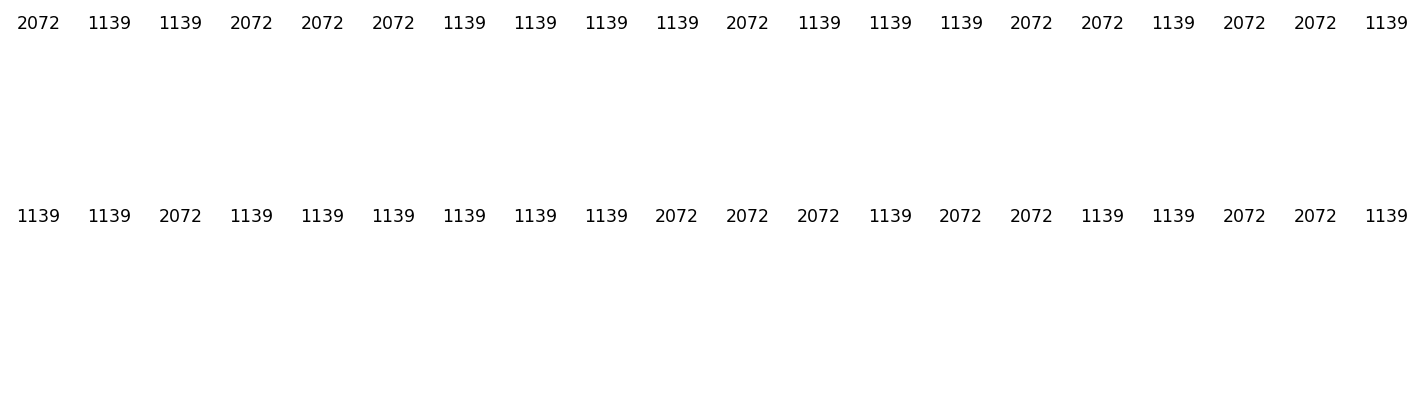

~~~~~~~~~~~~~~ mua units ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
title = number of spikes from each unit


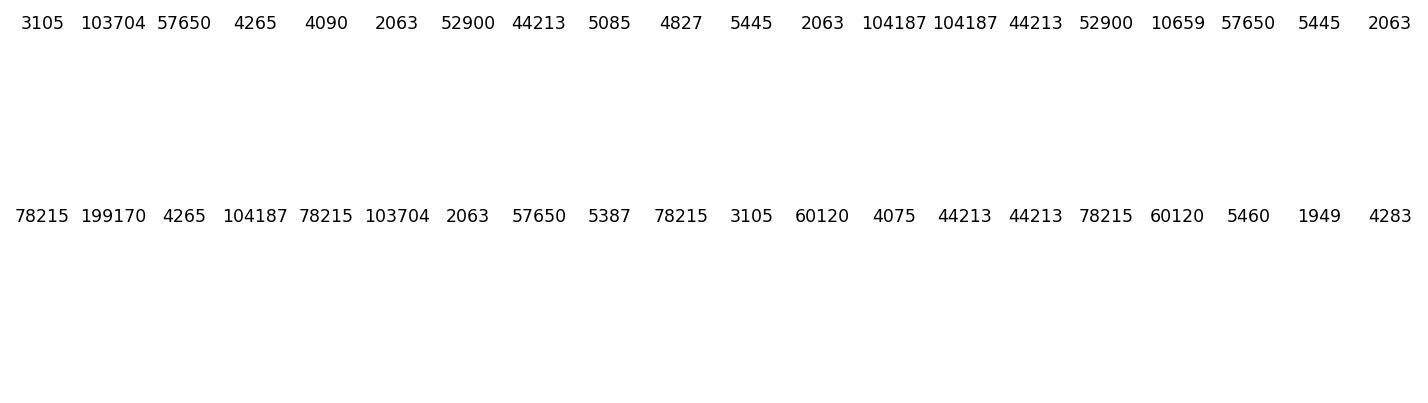

In [17]:
probe = ops['probe']
# x and y position of probe sites
xc, yc = probe['xc'], probe['yc']
nc = 16 # number of channels to show
good_units = np.nonzero(contam_pct <= 0.1)[0]
mua_units = np.nonzero(contam_pct > 0.1)[0]


gstr = ['good', 'mua']
for j in range(2):
    print(f'~~~~~~~~~~~~~~ {gstr[j]} units ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
    print('title = number of spikes from each unit')
    units = good_units if j==0 else mua_units
    fig = plt.figure(figsize=(12,3), dpi=150)
    grid = gridspec.GridSpec(2,20, figure=fig, hspace=0.25, wspace=0.5)

    for k in range(40):
        wi = units[np.random.randint(len(units))]
        wv = templates[wi].copy()
        cb = chan_best[wi]
        nsp = (clu==wi).sum()

        ax = fig.add_subplot(grid[k//20, k%20])
        n_chan = wv.shape[-1]
        ic0 = max(0, cb-nc//2)
        ic1 = min(n_chan, cb+nc//2)
        wv = wv[:, ic0:ic1]
        x0, y0 = xc[ic0:ic1], yc[ic0:ic1]

        amp = 4
        for ii, (xi,yi) in enumerate(zip(x0,y0)):
            t = np.arange(-wv.shape[0]//2,wv.shape[0]//2,1,'float32')
            t /= wv.shape[0] / 20
            ax.plot(xi + t, yi + wv[:,ii]*amp, lw=0.5, color='k')

        ax.set_title(f'{nsp}', fontsize='small')
        ax.axis('off')
    plt.show()

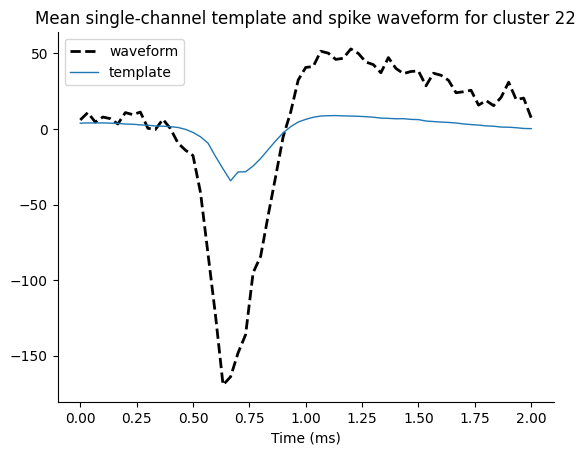

In [18]:
# Pick a random good cluster
cluster_id = get_good_cluster(results_dir, n=1)

# Get the mean spike waveform and mean templates for the cluster
mean_wv, spike_subset = mean_waveform(cluster_id, results_dir, n_spikes=100,
                                      bfile=None, best=True)
mean_temp = cluster_templates(cluster_id, results_dir, mean=True,
                              best=True, spike_subset=spike_subset)

# Get time in ms for visualization
ops = load_ops(results_dir / 'ops.npy')
t = (np.arange(ops['nt']) / ops['fs']) * 1000

fig, ax = plt.subplots(1,1)
ax.plot(t, mean_wv, c='black', linestyle='dashed', linewidth=2, label='waveform')
ax.plot(t, mean_temp, linewidth=1, label='template')
ax.set_title(f'Mean single-channel template and spike waveform for cluster {cluster_id}')
ax.set_xlabel('Time (ms)')
ax.legend()

In [ ]:
%matplotlib inline #qt

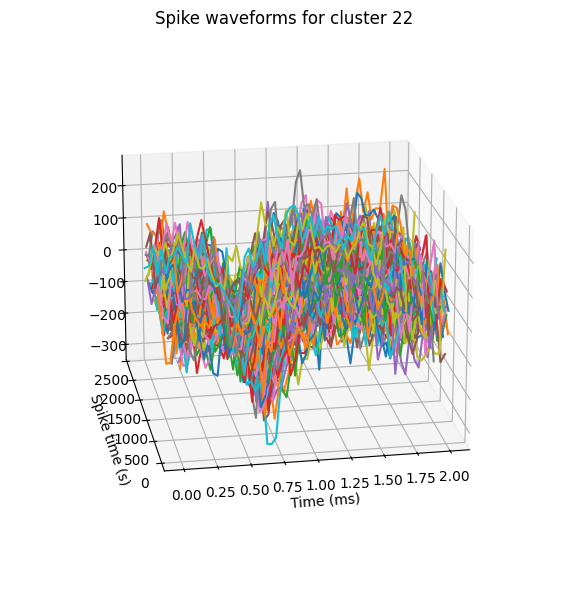

In [19]:

# Get n spike times for this cluster
spike_times, _ = get_cluster_spikes(cluster_id, results_dir, n_spikes=100)
# Time in s for spike time axis
t2 = spike_times / ops['fs']
# Get single-channel waveform for each spike
chan = get_best_channels(results_dir)[cluster_id]
waves = get_spike_waveforms(spike_times, results_dir, chan=chan)

# Plot each waveform, using spike time as 3rd dimension
fig, ax = plt.subplots(1, 1, figsize=(6,6), subplot_kw={'projection': '3d'})
for i in range(waves.shape[1]):
    # TODO: color by spike time
    ax.plot(t, t2[i], zs=waves[:,i], zdir='z')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spike time (s)')
ax.view_init(azim=-100, elev=20)
ax.set_title(f'Spike waveforms for cluster {cluster_id}')
ax.set_box_aspect(None, zoom=0.85)

plt.tight_layout()

Text(0, 0.5, 'Spike time (s)')

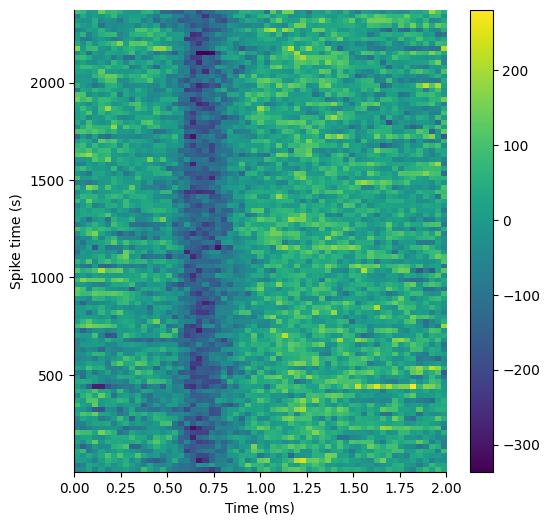

In [21]:
# Can also visualize this as a heatmap
fig2, ax2 = plt.subplots(1,1,figsize=(6,6))
pos = ax2.imshow(waves.T, aspect='auto', extent=[t[0], t[-1], t2[0], t2[-1]])
fig2.colorbar(pos, ax=ax2)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Spike time (s)')